[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SotaYoshida/book_NumericalAnalysis/blob/main/notebooks/Chap_InterpolationDifferentiationIntegration.ipynb)

# 補間・数値微分・数値積分

実験やシミュレーションでは、関数 $f$ の式そのものではなく、有限個の点における値だけが得られることが多い。そのデータから

- 点と点の間の値を求める**補間**、
- 変化率を求める**数値微分**、
- 区間全体の蓄積量を求める**数値積分**

を構成する。

三つは別々の公式に見えるが、共通しているのは「扱いやすい関数で近似し、その近似に必要な演算を行う」という考え方である。近似に用いる点の間隔を $h$ とすると、$h$ を小さくすることで離散化誤差を減らせる一方、丸め誤差、測定雑音、計算量の影響が現れる。本章でも、公式を適用して終わりにせず、刻み幅を変えて誤差の振る舞いを確かめる。

## この章の目標

- 補間と回帰、および補間と外挿の違いを説明できる。
- 2点・3点を結ぶ補間を、基底関数の重ね合わせとして説明できる。
- 区分多項式による張り合わせと、直交多項式による近似の特徴を説明できる。
- 前進差分と中心差分の使う点・誤差の違いを説明できる。
- 台形則とSimpson則を補間多項式の積分として説明できる。
- 誤差の次数を刻み幅の細分化実験から推定できる。
- 離散化誤差、丸め誤差、データ雑音を区別して方法を選べる。

:::{admonition} この章で使う数学（復習）
:class: note
- **Taylor展開**：$h$ が小さいとき、$f(x+h)\approx f(x)+hf'(x)+\frac{h^2}{2}f''(x)$。「現在の値＋傾き×移動量＋曲がり具合の補正」と読む。第1章のEuler法、第7章のNewton法も、この最初の2項を使っていた。
- **$O(h^p)$**：$h$ を小さくしたとき、誤差がおおよそ $h^p$ に比例して小さくなることを表す（第4章のBig-O記法の、小さな $h$ 版）。$p=2$ なら、$h$ を半分にすると誤差は約 $1/4$ になる。
- **定積分と面積**：$\int_a^bf(x)\,dx$ は、グラフと横軸の間の（符号付きの）面積である。数値積分は、この面積を台形などの簡単な図形の面積で近似する。

本章は、講義では2回に分けることを想定している。前半は補間と関数近似（「直交多項式」の節まで）、後半は数値微分と数値積分である。
:::



## 何を近似し、何を求めるのか

異なる点 $x_0,\ldots,x_n$ とデータ $y_i=f(x_i)$ が与えられたとする。

- **補間**は、すべての点を通る関数 $p$、すなわち $p(x_i)=y_i$ を作る。
- **回帰**は、一般にはすべての点を通ることを要求せず、残差全体が小さい関数を作る。
- **外挿**は、データの範囲 $[\min x_i,\max x_i]$ の外側で近似値を求める。

測定雑音を含むデータに対して高次多項式を厳密に通すと、雑音まで再現してしまう。補間は「データ点が正確」という仮定に適し、回帰は第6章で扱ったように「データに誤差がある」状況に適する。また外挿では、データから離れるほど形を拘束する情報がなくなるため、補間区間内より慎重な解釈が必要である。

例えば時刻0と2で温度が10と14なら、中間の時刻1は直線で結んで12と近似できる。同じ直線の傾きは2、区間の面積は24である。**一つの近似から、値・変化率・蓄積量を取り出す**のが本章の共通の考え方である。

本章の基本的な検証方法は、解析式が分かる関数から人工的にデータを作り、近似結果を真値と比較することである。このような既知解による試験を経てから、真値の分からない実データへ進む。


## 区分線形補間：局所的な近似をつなぐ

高次の多項式を区間全体に一つ作る代わりに、隣り合う2点を直線で結ぶのが**区分線形補間**である。$x_i\leq x\leq x_{i+1}$ なら

$$
p(x)=\frac{x_{i+1}-x}{x_{i+1}-x_i}y_i
+\frac{x-x_i}{x_{i+1}-x_i}y_{i+1}
$$

とする。二つの係数は非負で和が1なので、$p(x)$ は $y_i$ と $y_{i+1}$ の間にある。ある点のデータを変更しても影響は隣の区間に限られ、節点を追加することも容易である。

例えば3点 $(0,1),(1,2),(2,5)$ を考える。まず隣同士を直線で結ぶと、$[0,1]$ では $p(x)=1+x$、$[1,2]$ では $p(x)=3x-1$ となる。$x=0.5$ では両端に1/2ずつ重みを付けて1.5を得る。つなぎ目 $x=1$ では左右とも2なので関数は連続だが、傾きは1から3へ変わる。

同じ3点を一本の放物線 $q(x)=x^2+1$ で結ぶこともできる。これが**2次補間**であり、$x=0.5$ では1.25となる。点を通るという条件だけでなく、間をどの形でつなぐかも指定している。次の図で、節点では一致しても、その間では近似値が異なることを確かめよう。

```{figure} ../pic/interpolation_linear_quadratic.svg
:name: fig-interpolation-linear-quadratic
:width: 100%
:alt: 同じ3点を折れ線と放物線で結んだ比較。xが0.5のとき区分線形補間は1.5、2次補間は1.25。

左は隣り合う点を直線でつないだ区分線形補間、右は3点を通る2次補間。同じデータでも点の間の値は異なる。右の破線は比較のために重ねた区分線形補間である。
```

$f$ が2回連続微分可能なら、区間 $[x_i,x_{i+1}]$ における誤差はある $\xi$ を用いて

$$
f(x)-p(x)=\frac{f''(\xi)}{2}(x-x_i)(x-x_{i+1})
$$

と表せる。最大刻み幅を $h$ とすれば誤差は $O(h^2)$ である。したがって一様格子の刻み幅を半分にすると、十分細かい範囲では誤差がおよそ $1/4$ になると予想できる。



In [1]:
function linear_interpolate(xdata, ydata, x)
    length(xdata) == length(ydata) || error("xdataとydataの長さを同じにしてください")
    length(xdata) ≥ 2 && all(diff(xdata) .> 0) || error("2点以上を重複なく昇順に並べてください")
    first(xdata) ≤ x ≤ last(xdata) || error("補間区間の外です")

    i = min(searchsortedlast(xdata, x), length(xdata)-1)
    t = (x-xdata[i])/(xdata[i+1]-xdata[i])
    return (1-t)*ydata[i]+t*ydata[i+1]
end

function linear_max_error(f, nintervals)
    nodes = collect(range(0.0, π/2, length=nintervals+1))
    values = f.(nodes)
    testpoints = range(0.0, π/2, length=1001)
    return maximum(abs(linear_interpolate(nodes, values, x)-f(x)) for x in testpoints)
end

let previous = nothing
    for n in (4, 8, 16, 32)
        error = linear_max_error(sin, n)
        ratio = isnothing(previous) ? "---" : string(round(previous/error, digits=3))
        println("区間数=$n, 評価点上の最大誤差=$(round(error,sigdigits=5)), 前の誤差との比=$ratio")
        previous = error
    end
end


区間数=4, 評価点上の最大誤差=0.018846, 前の誤差との比=---
区間数=8, 評価点上の最大誤差=0.0047919, 前の誤差との比=3.933
区間数=16, 評価点上の最大誤差=0.001203, 前の誤差との比=3.983
区間数=32, 評価点上の最大誤差=0.00030092, 前の誤差との比=3.998


## 多項式補間とLagrange基底

### 各データの「担当」を作る

2次補間の放物線を、3点からどう組み立てればよいだろうか。先ほどの線形補間を $p(x)=y_0\ell_0(x)+y_1\ell_1(x)$ と書くと、

$$
\ell_0(x)=\frac{x_1-x}{x_1-x_0},\qquad
\ell_1(x)=\frac{x-x_0}{x_1-x_0}
$$

である。ここで $\ell_i$（小文字のエル、添字 $i$）は、データ $y_i$ に掛ける**重みを表す関数**である。$\ell_0$ は $x_0$ で1、$x_1$ で0なので、最初の点では $y_0$ だけが残る。$\ell_1$ はその逆を担当する。このように、重ね合わせて近似関数を作る部品を**基底関数**と呼ぶ。

3点 $x_0=0,x_1=1,x_2=2$ でも、「自分の点では1、ほかの点では0」という役割を持たせたい。最初の点を担当する $\ell_0$ は、$x=1,2$ で0になる必要があるため、まず $(x-1)(x-2)$ を作る。これを $x=0$ での値 $(0-1)(0-2)=2$ で割れば、そこで1になる。

$$
\ell_0(x)=\frac{(x-1)(x-2)}{(0-1)(0-2)}
=\frac{(x-1)(x-2)}{2}.
$$

同じ作り方で残りの二つも求めると、

$$
\ell_1(x)=\frac{x(x-2)}{(1-0)(1-2)}=-x(x-2),\qquad
\ell_2(x)=\frac{x(x-1)}{(2-0)(2-1)}=\frac{x(x-1)}{2}
$$

となる。あとは各データの高さを掛けて足せばよい。$y_0=1,y_1=2,y_2=5$ なら

$$
p_2(x)=1\ell_0(x)+2\ell_1(x)+5\ell_2(x)=x^2+1.
$$

例えば $x=0.5$ では $(\ell_0,\ell_1,\ell_2)=(3/8,3/4,-1/8)$ なので、$p_2(0.5)=3/8+2\times3/4-5/8=1.25$ となる。線形補間と違い、2次以上では重みが負になることもある。

```{figure} ../pic/interpolation_lagrange_basis.svg
:name: fig-interpolation-lagrange-basis
:width: 100%
:alt: 3個のLagrange基底は担当する節点で1、他の節点で0となる。各基底にデータ値を掛けて足すと2次補間多項式になる。

左は各点を担当する $\ell_0,\ell_1,\ell_2$。右は高さを掛けた $y_i\ell_i$ と、その和 $p_2$ である。各節点では一つの項だけが残り、指定された値を再現する。
```

### 一般の点数へ広げる

$n+1$ 個の異なる点 $(x_i,y_i)$ をすべて通る次数 $n$ 以下の多項式は一意に存在する。上の作り方を一般化した **Lagrange（ラグランジュ）基底**は

$$
\ell_i(x)=\prod_{\substack{j=0\\j\neq i}}^n
\frac{x-x_j}{x_i-x_j}
$$

であり、$\ell_i(x_i)=1$、$j\neq i$ なら $\ell_i(x_j)=0$ を満たす。したがって

$$
p_n(x)=\sum_{i=0}^n y_i\ell_i(x)
$$

と置けば、確かに $p_n(x_i)=y_i$ となる。

先ほどの3点は $y=x^2+1$ 上の点であり、2次補間で元の式を完全に再現できた。一般に次数 $n$ 以下の多項式を $n+1$ 点で補間すれば、丸め誤差を除いて完全に再現できる。この**多項式再現性**は実装を検証するよい試験になる。



In [2]:
function lagrange_interpolate(xdata, ydata, x)
    length(xdata) == length(ydata) || error("xdataとydataの長さを同じにしてください")
    n = length(xdata)
    n > 0 && length(unique(xdata)) == n || error("異なる補間点が必要です")
    value = 0.0
    for i in 1:n
        basis = 1.0
        for j in 1:n
            i == j && continue
            basis *= (x-xdata[j])/(xdata[i]-xdata[j])
        end
        value += ydata[i]*basis
    end
    return value
end

xdata = [0.0, 1.0, 2.0]
ydata = xdata.^2 .+ 1
for x in (0.5, 1.5)
    p = lagrange_interpolate(xdata, ydata, x)
    println("x=$x: 補間値=$p, 真値=$(x^2+1), 誤差=$(abs(p-(x^2+1)))")
end


x=0.5: 補間値=1.25, 真値=1.25, 誤差=0.0
x=1.5: 補間値=3.25, 真値=3.25, 誤差=0.0


## 関数を張り合わせる・重ね合わせる

区分線形補間は、小区間ごとの直線をつなぐ方法だった。これを、区間全体で定義した基底関数の和として見ることもできる。各節点 $x_i$ で高さ1、隣の節点で0となり、その外では0の**帽子型関数** $\phi_i$ を作る。端の節点では片側だけの形にする。すると区分線形補間は

$$
p_h(x)=\sum_{i=0}^{n}y_i\phi_i(x)
$$

と書ける。小区間 $[x_i,x_{i+1}]$ の内部では $\phi_i,\phi_{i+1}$ だけが0でなく、先ほどの線形補間の二つの重みと一致する。各部品が連続なので、その和も連続になる。

```{figure} ../pic/approximation_local_basis.svg
:name: fig-approximation-local-basis
:width: 100%
:alt: 帽子型の局所基底と、その高さをsin関数の節点値に合わせて足した区分線形近似。

左の帽子型関数を、右ではデータ値 $y_i=\sin x_i$ 倍して重ねる。色付きの各成分を足した赤い折れ線は、節点では黒い $\sin x$ と一致し、その間を近似する。この基底では、一つのデータを変えた影響は隣接区間に限られる。
```

ここには二つの見方がある。

- **張り合わせる**：区間を分け、各区間に低次の多項式を置いて、境界で値を一致させる。さらに導関数もつなぐと滑らかさを高められる。例えば3次スプライン（spline）では、区間ごとの3次多項式を、通常は2階導関数まで連続になるようにつなぐ。帽子型関数は、微分方程式を小さな領域に分けて解く有限要素法でも使われる。
- **重ね合わせる**：基底関数 $\phi_k$ を選び、$p_N(x)=\sum_{k=0}^{N}a_k\phi_k(x)$ として形を作る。局所的な帽子型関数も、区間全体に広がる多項式も、この表現に含まれる。

したがって、近似を設計する際には「どの基底を使うか」と「係数をどう決めるか」を考える。補間では節点で値を一致させたが、区間全体の誤差を小さくするように係数を決めることもできる。次の直交多項式は、その計算を簡単にする基底である。



## 直交多項式：関数近似のための基底

### 直交すると、係数を一つずつ取り出せる

:::{tip}
この節は本章で最も数式が多い。初めて読むときは、「ベクトルを直交する方向に分解すると各成分を内積で取り出せる（第6章のQR分解）。関数でも同じことができる」という考え方と、直後の図だけを押さえれば、数値微分以降の節は読み進められる。
:::

ベクトルを互いに直交する方向に分解したとき、各成分は内積で求められた。関数も同様に考えられる。実数値関数同士の内積を、まず区間 $[-1,1]$ で

$$
\langle p,q\rangle=\int_{-1}^{1}p(x)q(x)\,dx
$$

と定める。多項式 $1,x,x^2,\ldots$ は線形独立だが、例えば $\langle 1,x^2\rangle=2/3$ なので互いに直交してはいない。そこで、次数 $k$ の多項式 $P_k$ を選び直して

$$
\langle P_j,P_k\rangle=0\qquad(j\neq k)
$$

となるようにする。こうした多項式列を**直交多項式**という。「直交」は、グラフが直角に交わるという意味ではなく、積を区間全体で積分すると0になるという意味である。

$f$ を $p_N=\sum_{k=0}^{N}a_kP_k$ で近似し、区間全体の二乗誤差

$$
E=\|f-p_N\|^2=\int_{-1}^{1}\{f(x)-p_N(x)\}^2\,dx
$$

を最小にしたい。係数 $a_j$ で微分すると $\partial E/\partial a_j=-2\langle f-p_N,P_j\rangle$ だから、最小となる条件は「残差が各基底と直交すること」である。直交性を使えば

$$
\langle f,P_j\rangle
=\sum_{k=0}^{N}a_k\langle P_k,P_j\rangle
=a_j\langle P_j,P_j\rangle,
\qquad
 a_j=\frac{\langle f,P_j\rangle}{\langle P_j,P_j\rangle}
$$

と係数を個別に取り出せる。一般の基底なら連立方程式になるところで、異なる基底間の項が消えるのである。これは[第6章の最小二乗法](Chap_QRLeastSquares.ipynb)の連続関数版であり、$p_N$ を $f$ の**直交射影**と呼ぶ。この係数の決め方では、特定の節点を必ず通るという条件は課していない。

### Legendre多項式で形を組み立てる

区間 $[-1,1]$、重み1に対する代表例がLegendre（ルジャンドル）多項式である。最初の四つは

$$
P_0(x)=1,\qquad
P_1(x)=x,\qquad
P_2(x)=\frac{3x^2-1}{2},\qquad
P_3(x)=\frac{5x^3-3x}{2}.
$$

定数の成分、傾きの成分、曲がりの成分、というように異なる形を足していくと考えよう。例えば $\int_{-1}^{1}P_0P_2\,dx=\frac12\int_{-1}^{1}(3x^2-1)\,dx=0$ であり、$P_2$ の正の部分と負の部分が打ち消し合う。

漸化式

$$
(n+1)P_{n+1}(x)=(2n+1)xP_n(x)-nP_{n-1}(x),\qquad n\geq1
$$

を $P_0=1,P_1=x$ から使えば、高次の多項式も順に計算できる。また

$$
\int_{-1}^{1}P_j(x)P_k(x)\,dx=\frac{2}{2k+1}\delta_{jk},
\qquad
 a_k=\frac{2k+1}{2}\int_{-1}^{1}f(x)P_k(x)\,dx
$$

である。$\delta_{jk}$ は $j=k$ のとき1、それ以外で0となるKroneckerのデルタである。直交していても長さが1とは限らず、ここでは $\|P_k\|^2=2/(2k+1)$ で割る必要がある。



In [3]:
# 補間・局所基底・直交多項式の4図をまとめて再生成する。
# 初回のみ: import Pkg; Pkg.add("CairoMakie")
using CairoMakie
CairoMakie.activate!(type="svg")
set_theme!(Theme(fontsize=16, linewidth=2.5))
figure_dir = isdir("pic") ? "pic" : joinpath("..", "pic")

function legendre_plot(n, x)
    n == 0 && return one(x)
    p0, p1 = one(x), x
    for k in 1:n-1
        p0, p1 = p1, ((2k+1)*x*p1-k*p0)/(k+1)
    end
    return p1
end

let
    colors = [:dodgerblue, :darkorange, :seagreen, :purple, :crimson]
    nodes = [0.0, 1.0, 2.0]
    values = [1.0, 2.0, 5.0]
    xs = collect(range(0.0, 2.0, length=501))
    linear = [linear_interpolate(nodes, values, x) for x in xs]
    quadratic = [lagrange_interpolate(nodes, values, x) for x in xs]

    fig = Figure(size=(1000, 440))
    for (column, ys, title, label, value) in (
        (1, linear, "Piecewise linear interpolation", "p(x): joined lines", 1.5),
        (2, quadratic, "Quadratic interpolation", "q(x) = x² + 1", 1.25))
        ax = Axis(fig[1, column]; xlabel="x", ylabel="value", title=title,
            xticks=[0, 0.5, 1, 2])
        column == 2 && lines!(ax, xs, linear; color=:gray60, linestyle=:dash,
            label="piecewise linear")
        lines!(ax, xs, ys; color=:tomato, label=label)
        scatter!(ax, nodes, values; color=:black, markersize=12, label="data")
        lines!(ax, [0.5, 0.5], [0.5, value]; color=:gray55, linestyle=:dot)
        scatter!(ax, [0.5], [value]; color=:dodgerblue, markersize=13)
        text!(ax, 0.57, value-0.28; text="x = 0.5: $value", fontsize=15,
            color=:dodgerblue, align=(:left, :top))
        xlims!(ax, -0.08, 2.08)
        ylims!(ax, 0.45, 5.4)
        axislegend(ax; position=:lt, labelsize=14)
    end
    save(joinpath(figure_dir, "interpolation_linear_quadratic.svg"), fig)

    # データ値が一つだけ1の補間から、各Lagrange基底を作る。
    basis = [[lagrange_interpolate(nodes, Float64.(eachindex(nodes) .== i), x)
              for x in xs] for i in eachindex(nodes)]
    fig = Figure(size=(1000, 470))
    ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="basis value",
        title="One basis function for each node", xticks=nodes)
    ax2 = Axis(fig[1, 2]; xlabel="x", ylabel="value",
        title="Scale by data values, then add", xticks=nodes)
    for i in eachindex(nodes)
        lines!(ax1, xs, basis[i]; color=colors[i], label="ℓ$(i-1)(x)")
        scatter!(ax1, nodes, Float64.(eachindex(nodes) .== i);
            color=colors[i], markersize=12-2i)
        lines!(ax2, xs, values[i].*basis[i]; color=colors[i],
            label="$(Int(values[i])) ℓ$(i-1)(x)")
    end
    lines!(ax2, xs, quadratic; color=:black, linewidth=3, label="sum: x² + 1")
    scatter!(ax2, nodes, values; color=:black, markersize=11)
    ylims!(ax1, -0.22, 1.15)
    Legend(fig[2, 1], ax1; orientation=:horizontal, labelsize=14)
    Legend(fig[2, 2], ax2; orientation=:horizontal, nbanks=2, labelsize=14)
    save(joinpath(figure_dir, "interpolation_lagrange_basis.svg"), fig)

    # 帽子型基底も、データ値が一つだけ1の区分線形補間として作れる。
    local_nodes = collect(range(0.0, π, length=5))
    local_values = sin.(local_nodes)
    local_x = collect(range(0.0, π, length=601))
    hats = [[linear_interpolate(local_nodes, Float64.(eachindex(local_nodes) .== i), x)
             for x in local_x] for i in eachindex(local_nodes)]
    fig = Figure(size=(1000, 470))
    ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="basis value", title="Local hat functions")
    ax2 = Axis(fig[1, 2]; xlabel="x", ylabel="value", title="Join local pieces to approximate sin(x)")
    for i in eachindex(local_nodes)
        lines!(ax1, local_x, hats[i]; color=colors[i], label="φ$(i-1)(x)")
        lines!(ax2, local_x, local_values[i].*hats[i]; color=(colors[i], 0.7),
            linestyle=:dash, linewidth=1.8)
    end
    lines!(ax2, local_x, sin.(local_x); color=:black, label="sin(x)")
    lines!(ax2, local_x, sum(local_values[i].*hats[i] for i in eachindex(local_nodes));
        color=:tomato, linewidth=3, label="sum: piecewise linear")
    scatter!(ax2, local_nodes, local_values; color=:black, markersize=10, label="data")
    for ax in (ax1, ax2)
        ax.xticks = ([0, π/4, π/2, 3π/4, π], ["0", "π/4", "π/2", "3π/4", "π"])
        ylims!(ax, -0.08, 1.12)
    end
    Legend(fig[2, 1], ax1; orientation=:horizontal, nbanks=2, labelsize=14)
    Legend(fig[2, 2], ax2; orientation=:horizontal, nbanks=2, labelsize=14)
    save(joinpath(figure_dir, "approximation_local_basis.svg"), fig)

    # fと次数を変えて、直交射影の様子を調べる。
    f = exp
    degrees = [0, 1, 2, 4]
    projection_x = collect(range(-1.0, 1.0, length=4001))
    dx = projection_x[2]-projection_x[1]
    integration_weights = fill(dx, length(projection_x))
    integration_weights[[1, end]] .*= 0.5  # 複合台形則の端点の重み
    coefficients = [(2k+1)/2 * sum(integration_weights .* f.(projection_x) .*
                    legendre_plot.(k, projection_x)) for k in 0:maximum(degrees)]
    plot_x = collect(range(-1.0, 1.0, length=601))
    fig = Figure(size=(1000, 470))
    ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="basis value", title="Legendre polynomials")
    ax2 = Axis(fig[1, 2]; xlabel="x", ylabel="value", title="Orthogonal projections of exp(x)")
    for k in 0:3
        lines!(ax1, plot_x, legendre_plot.(k, plot_x); color=colors[k+1], label="P$k(x)")
    end
    lines!(ax2, plot_x, f.(plot_x); color=:black, linewidth=4, label="exp(x)")
    for (i, degree) in enumerate(degrees)
        approximation = sum(coefficients[k+1].*legendre_plot.(k, plot_x) for k in 0:degree)
        lines!(ax2, plot_x, approximation; color=colors[i],
            linestyle=degree == 4 ? :dash : :solid, label="N = $degree")
    end
    Legend(fig[2, 1], ax1; orientation=:horizontal, nbanks=2, labelsize=14)
    Legend(fig[2, 2], ax2; orientation=:horizontal, nbanks=2, labelsize=14)
    save(joinpath(figure_dir, "orthogonal_polynomial_approximation.svg"), fig)
end



CairoMakie.Screen{SVG}


```{figure} ../pic/orthogonal_polynomial_approximation.svg
:name: fig-orthogonal-polynomial-approximation
:width: 100%
:alt: Legendre多項式P0からP3の形と、それらの重ね合わせによるexp関数の近似。次数0、1、2、4の近似を比較。

左はLegendre基底の形、右は $f(x)=e^x$ の近似 $p_N=\sum_{k=0}^{N}a_kP_k$ である。$N=0$ では定数だけ、$N=1$ で傾き、$N=2$ で曲がりを加える。$N=4$ の曲線はこの表示では真の関数とほぼ重なる。係数の積分は細かい格子上の複合台形則で評価した。
```

### 利点と使う場面

直交多項式の利点は、次のように整理できる。

- **係数の計算が分かれる**：各係数を内積一つで求められる。規格化した基底では内積の行列が単位行列となり、単項式基底で生じやすい係数間の強い結び付きを避けられる。ただし、積分を標本値の和に置き換える場合、標本点と重みが適切でなければ直交性は保たれない。
- **成分を足して精度を上げられる**：同じ内積で厳密に射影する限り、$P_{N+1}$ を加えても既存の係数は変わらず、二乗誤差は $\|f-p_{N+1}\|^2=\|f-p_N\|^2-a_{N+1}^2\|P_{N+1}\|^2$ だけ減る。これは区間全体の誤差についての性質であり、すべての点で誤差が単調に減るという意味ではない。
- **別の数値計算にも利用できる**：滑らかな関数を少数の係数で保存・評価する近似、微分方程式の解を基底で展開するスペクトル法、少ない評価点で積分するGauss型求積法に用いられる。求積法では、後で見るように直交多項式の零点が標本点になる。

### Legendre以外にも、区間と重みに合わせて選ぶ

直交性は、区間と内積の選び方に依存する。一般には、正の重み $w(x)$ を使って

$$
\langle p,q\rangle_w=\int_a^b p(x)q(x)w(x)\,dx
$$

と定める。重みは、どの領域の誤差を重視するかを表す。係数の公式も同じで、内積を $\langle\cdot,\cdot\rangle_w$ に置き換えればよい。

| 多項式 | 区間 | 重み $w(x)$ | 活用の例 |
|---|---|---|---|
| Legendre $P_n$ | $[-1,1]$ | $1$ | 有限区間の関数近似、Gauss--Legendre積分 |
| Chebyshev $T_n$（第1種） | $[-1,1]$ | $1/\sqrt{1-x^2}$ | 関数の多項式近似、後述する端に密な補間点との関係 |
| Laguerre $L_n$ | $[0,\infty)$ | $e^{-x}$ | 半無限区間の重み付き積分 |
| Hermite $H_n$（物理で使う規約） | $(-\infty,\infty)$ | $e^{-x^2}$ | Gaussian型の重みを持つ積分 |

区間・重み・規格化の対応は [NIST DLMF §18.3](https://dlmf.nist.gov/18.3)、近似への応用は [§18.38](https://dlmf.nist.gov/18.38) にまとめられている。これらの名前を暗記するよりも、**対象の区間と誤差の測り方に合わせて、近似の基底を選ぶ**という考え方を押さえよう。



## 数値微分：近くの値から傾きを求める

ここまでは、与えられたデータや関数から近似関数を作ってきた。ここからは、その考え方を傾きや面積の計算に使う。まず2点を結ぶ直線の傾きに戻り、数値微分を考えよう。

以下の表では、刻みを半分にしたときの誤差比から次数を読む。誤差が $Ch^p$ 程度なら、誤差比は約 $2^p$、その `log2` が約 $p$ になる。1次なら約半分、2次なら約1/4という意味である。

傾きは「値の変化／位置の変化」で近似できる。前章の割線法で使った2点の傾きと同じ発想である。ここでは、点を近づけると近似がどの程度改善するかを見る。

十分滑らかな $f$ のTaylor展開

$$
f(x+h)=f(x)+hf'(x)+\frac{h^2}{2}f''(x)+O(h^3)
$$

を $f'(x)$ について解くと、**前進差分**

$$
D_+f(x)=\frac{f(x+h)-f(x)}{h}=f'(x)+O(h)
$$

を得る。$f(x-h)$ の展開も用意し、両者の差を取れば偶数次の項が消えて、**中心差分**

$$
D_0f(x)=\frac{f(x+h)-f(x-h)}{2h}=f'(x)+O(h^2)
$$

を得る。十分滑らかな関数で $h$ が適度に小さければ、中心差分の誤差は通常小さくなるが、端点では区間外の $f(x-h)$ が必要になる。

同様に二つの展開の和を取ると、2階微分の中心差分

$$
f''(x)=\frac{f(x-h)-2f(x)+f(x+h)}{h^2}+O(h^2)
$$

が得られる。例えば $f(x)=x^2$ なら分子は $2h^2$ となり、厳密な2階微分2を再現する。



In [4]:
fexp(x) = exp(x)
x0 = 1.0
exact_derivative = exp(x0)

let previous_forward = nothing, previous_central = nothing
    for h in (0.2, 0.1, 0.05, 0.025)
        forward = (fexp(x0+h)-fexp(x0))/h
        central = (fexp(x0+h)-fexp(x0-h))/(2h)
        ef = abs(forward-exact_derivative)
        ec = abs(central-exact_derivative)
        pf = isnothing(previous_forward) ? "---" : string(round(log2(previous_forward/ef), digits=3))
        pc = isnothing(previous_central) ? "---" : string(round(log2(previous_central/ec), digits=3))
        println("h=$h: 前進差分の誤差=$(round(ef,sigdigits=4)) (次数 $pf), " *
                "中心差分の誤差=$(round(ec,sigdigits=4)) (次数 $pc)")
        previous_forward, previous_central = ef, ec
    end
end


h=0.2: 前進差分の誤差=0.2909 (次数 ---), 中心差分の誤差=0.01816 (次数 ---)
h=0.1: 前進差分の誤差=0.1406 (次数 1.049), 中心差分の誤差=0.004533 (次数 2.002)
h=0.05: 前進差分の誤差=0.0691 (次数 1.024), 中心差分の誤差=0.001133 (次数 2.001)
h=0.025: 前進差分の誤差=0.03426 (次数 1.012), 中心差分の誤差=0.0002832 (次数 2.0)


## 刻み幅を小さくしすぎると何が起こるか

差分公式には二種類の誤差がある。

1. Taylor展開の高次項を捨てる**離散化誤差**は、$h$ を小さくすると減る。
2. 近い二数 $f(x+h)$ と $f(x)$ の引き算で有効桁が失われ、その差を $h$ で割ることで**丸め誤差**が増幅される。

前進差分の誤差を概略

$$
C_1h+C_2\frac{\varepsilon_{\mathrm{mach}}}{h}
$$

と考えると、前者は $h$ とともに減るが後者は増える。中心差分では、同じ見積もりの離散化項を $C_1h^2$ と考える。したがって「可能な限り小さな $h$」が最良ではなく、両者が釣り合う範囲に最適な刻み幅がある。測定データを微分する場合は、丸め誤差に加えてデータ雑音も $1/h$ 程度に増幅されるため、さらに注意が必要である。


In [5]:
println("中心差分でhを小さくし続けた場合")
for h in 10.0 .^ (-1:-2:-15)
    approximation = (fexp(x0+h)-fexp(x0-h))/(2h)
    println("h=$(h): 誤差=$(abs(approximation-exact_derivative))")
end

中心差分でhを小さくし続けた場合
h=0.1: 誤差=0.00453273548837263
h=0.001: 誤差=4.53046678838831e-7
h=1.0e-5: 誤差=5.858691309867936e-11
h=1.0e-7: 誤差=5.858735718788921e-11
h=1.0e-9: 誤差=6.60275079056305e-9
h=1.0e-11: 誤差=1.0429493680685908e-5
h=1.0e-13: 誤差=0.00045586417666187984
h=1.0e-15: 誤差=0.16829803556636147


In [6]:
using CairoMakie
CairoMakie.activate!(type="svg")
set_theme!(Theme(fontsize=16, linewidth=2.5))
figure_dir = isdir("pic") ? "pic" : joinpath("..", "pic")

x0_diff = 1.0
exact_diff = exp(x0_diff)
h_values = 10.0 .^ range(-16, -1, length=180)
forward_errors = [abs((exp(x0_diff+h)-exp(x0_diff))/h-exact_diff) for h in h_values]
centered_errors = [abs((exp(x0_diff+h)-exp(x0_diff-h))/(2h)-exact_diff) for h in h_values]

fig_differentiation = Figure(size=(850, 490))
ax = Axis(fig_differentiation[1, 1];
    xlabel="step size h", ylabel="absolute error",
    xscale=log10, yscale=log10,
    title="Truncation error versus roundoff")
lines!(ax, h_values, max.(forward_errors, eps());
    color=:orange, label="forward difference")
lines!(ax, h_values, max.(centered_errors, eps());
    color=:dodgerblue, label="centered difference")
axislegend(ax; position=:rt)
save(joinpath(figure_dir, "differentiation_step_size.svg"), fig_differentiation)

CairoMakie.Screen{SVG}


```{figure} ../pic/differentiation_step_size.svg
:name: fig-differentiation-step-size
:width: 90%
:alt: 前進差分と中心差分の刻み幅に対する微分誤差

右側では刻みを小さくすると打切り誤差が減るが、左側では近い数の差による丸め誤差が支配する。したがって、刻み幅は小さければ小さいほどよいわけではない。
```


## 数値積分：面積を近似関数の面積で置き換える

定積分

$$
I=\int_a^b f(x)\,dx
$$

を有限個の関数値から近似する公式を**求積公式**という。台形則は、$f$ を端点 $(a,f(a))$ と $(b,f(b))$ を結ぶ直線で補間し、その直線を積分することで得られる。

$$
T_1=\frac{b-a}{2}\{f(a)+f(b)\}
$$

区間を $n$ 等分して各小区間に台形則を適用すると、**複合台形則**

$$
T_n=h\left[\frac{f(a)+f(b)}{2}+\sum_{i=1}^{n-1}f(a+ih)\right],
\qquad h=\frac{b-a}{n}
$$

を得る。$f$ が十分滑らかなら大域的な誤差は $O(h^2)$ である。各内部点が左右の台形に半分ずつ現れるため、まとめると重みが1になる。


```{figure} ../pic/learning_trapezoids.svg
:name: fig-learning-trapezoids
:width: 85%
:alt: 2個の台形で曲線下の面積を近似する。中央の関数値は左右の台形の式にそれぞれ半分ずつ現れる。

黒い曲線を、隣の節点を結ぶ青い破線で置き換え、その下の色付き面積を足す。$h=1$、$f_i=f(x_i)$ の例では、中央の高さ $f_1$ が左右から $h/2$ ずつ寄与し、合計の係数は $h$ になる。端点の高さは1回しか現れず、係数は $h/2$ のままである。
```


In [7]:
function trapezoid(f, a, b, n)
    n > 0 || error("nは正にしてください")
    h = (b-a)/n
    sum = (f(a)+f(b))/2
    for i in 1:n-1
        sum += f(a+i*h)
    end
    return h*sum
end

exact_integral = 2.0  # integral of sin(x) on [0,π]
let previous = nothing
    for n in (10, 20, 40, 80)
        error = abs(trapezoid(sin, 0.0, π, n)-exact_integral)
        order = isnothing(previous) ? "---" : string(round(log2(previous/error), digits=3))
        println("n=$n: 誤差=$(round(error,sigdigits=5)), 観測次数=$order")
        previous = error
    end
end


n=10: 誤差=0.016476, 観測次数=---
n=20: 誤差=0.004114, 観測次数=2.002
n=40: 誤差=0.0010282, 観測次数=2.0
n=80: 誤差=0.00025703, 観測次数=2.0


## Simpson則：2次補間を積分する

三つの等間隔点 $x_0,x_1,x_2$ を通る2次補間多項式を積分すると、

$$
\int_{x_0}^{x_2}f(x)\,dx
\approx\frac{h}{3}\{f(x_0)+4f(x_1)+f(x_2)\},
\qquad h=x_1-x_0
$$

を得る。例えば $f(x)=x^2$ を $[0,2]$ で積分すると、$h=1$、値は0、1、4なので $(0+4\times1+4)/3=8/3$ となり、厳密な積分と一致する。これを2小区間ずつ適用したものが**複合Simpson則**である。小区間数 $n$ は偶数でなければならず、

$$
S_n=\frac{h}{3}\left[f(x_0)+f(x_n)
+4\sum_{i\ \mathrm{odd}}f(x_i)
+2\sum_{\substack{i\ \mathrm{even}\\i\neq0,n}}f(x_i)\right]
$$

となる。十分滑らかな関数に対する誤差は $O(h^4)$ である。Simpson則は2次補間から導かれるが、対称性による打ち消しのため3次多項式まで厳密に積分できる。


In [8]:
function simpson(f, a, b, n)
    n > 0 && iseven(n) || error("nは正の偶数にしてください")
    h = (b-a)/n
    sum = f(a)+f(b)
    for i in 1:n-1
        sum += (isodd(i) ? 4 : 2)*f(a+i*h)
    end
    return h*sum/3
end

let previous = nothing
    for n in (4, 8, 16, 32)
        error = abs(simpson(sin, 0.0, π, n)-exact_integral)
        order = isnothing(previous) ? "---" : string(round(log2(previous/error), digits=3))
        println("n=$n: 誤差=$(round(error,sigdigits=5)), 観測次数=$order")
        previous = error
    end
end

println("3次多項式の積分誤差 = ", abs(simpson(x -> x^3, 0.0, 1.0, 2)-1/4))


n=4: 誤差=0.0045598, 観測次数=---
n=8: 誤差=0.00026917, 観測次数=4.082
n=16: 誤差=1.6591e-5, 観測次数=4.02
n=32: 誤差=1.0334e-6, 観測次数=4.005
3次多項式の積分誤差 = 0.0


## 式が分からず、データしかない場合

ここまでは $\sin x$ のように式が分かる関数を使い、真値と比べて誤差の次数を確かめた。実際の業務では、決まった時刻に測った値しか手元にないことが多い。例えば、ある店舗で毎正時に「その時点の来客ペース（人/時）」を記録したとする。1日の来客数は、このペースを時間で積分したものである。

データ点の間隔が一定でない場合にも使えるよう、隣り合う2点ごとに台形の面積を足す関数 `trapezoid_data` を用意する。Simpson則は等間隔で小区間の数が偶数のときに使える。


In [9]:
function trapezoid_data(x, y)
    length(x) == length(y) && length(x) ≥ 2 || error("2点以上の同じ長さのデータが必要です")
    all(diff(x) .> 0) || error("xは昇順に並べてください")
    return sum((x[i+1]-x[i])*(y[i]+y[i+1])/2 for i in 1:length(x)-1)
end

function simpson_data(y, h)
    n = length(y) - 1                        # 小区間の数
    n ≥ 2 && iseven(n) || error("小区間の数は正の偶数にしてください")
    return h/3*(y[1] + y[end] + 4*sum(y[2:2:end-1]) + 2*sum(y[3:2:end-2]))
end

hours = collect(9.0:1.0:21.0)                                           # 9時〜21時の毎正時
visitors_per_hour = [12.0, 20, 31, 55, 62, 40, 28, 30, 45, 70, 58, 30, 10]  # その時刻の来客ペース（人/時）

println("台形則（1時間おき） = ", trapezoid_data(hours, visitors_per_hour), " 人")
println("Simpson則（1時間おき） = ", round(simpson_data(visitors_per_hour, 1.0), digits=1), " 人")
println("台形則（2時間おきのデータだけ） = ",
        trapezoid_data(hours[1:2:end], visitors_per_hour[1:2:end]), " 人")

台形則（1時間おき） = 480.0 人
Simpson則（1時間おき） = 483.3 人
台形則（2時間おきのデータだけ） = 470.0 人


1時間おきのデータで、台形則は480人、Simpson則は約483人となった。2時間おきのデータだけを使った台形則は470人である。

ここで、次の点に注意しよう。

- **真値がない。** 式が分かる場合のように、誤差を直接測ることはできない。
- **刻み幅を細かくできない。** 30分おきのデータは存在しないので、「$h$ を半分にして変化を見る」検証もそのままでは使えない。代わりに、データを間引いて粗くした結果（470人）と比べたり、異なる公式（台形則とSimpson則）の差を見たりすると、離散化による不確かさの**目安**が得られる。この例では数人〜十数人程度である。
- **公式の次数が意味を持つとは限らない。** Simpson則が4次精度になるのは、関数が十分滑らかな場合である。来客ペースには昼食時の急な増減や、記録の誤差（雑音）も含まれる。データが滑らかでなければ、高次の公式が低次の公式より正確だとは言えない。

このように、データからの積分では、離散化誤差・測定誤差・データの粗さを区別して、結果にどの程度の幅があるかを報告することが大切である。


## 方法を選び、結果を確かめる

| 求めたいもの | 出発点 | 確認すること |
|---|---|---|
| 点と点の間の値 | 区分線形補間 | データ点を通るか、範囲内か |
| 区間全体の関数近似 | 直交多項式による展開 | 内積の区間・重みは適切か、次数を変えると二乗誤差が減るか |
| 変化率 | 前進差分・中心差分 | 刻みを細かくすると改善するか、雑音を増幅していないか |
| 区間の積分 | 台形則・Simpson則 | 一定値や低次多項式を再現するか、分割数による変化 |

既知の関数で試してから実データへ進む。真値がない場合も、分割数を変えた結果の差は判断材料になる。ただし、その差が小さいことだけで精度を保証できるとは限らない。



## $\clubsuit$ 高次多項式補間と点の配置

「点を増やして多項式の次数を上げれば、必ずよい近似になる」とは限らない。等間隔点で

$$
r(x)=\frac{1}{1+25x^2},\qquad -1\leq x\leq1
$$

を高次補間すると、区間の端付近で大きな振動が生じることがある。これはRunge現象と呼ばれる。

補間誤差は

$$
f(x)-p_n(x)=\frac{f^{(n+1)}(\xi)}{(n+1)!}
\prod_{i=0}^n(x-x_i)
$$

と表され、関数の高階微分だけでなく点の配置にも依存する。端に密なChebyshev点

$$
x_i=\cos\frac{i\pi}{n},\qquad i=0,\ldots,n
$$

を使うと、積 $\prod_i(x-x_i)$ の増大を抑えられる。また実用上は、全区間を一つの高次多項式で結ぶより、低次の区分多項式を滑らかにつないだスプラインがよく用いられる。

以下は現象を確認するための単純なLagrange評価である。大規模な補間では、同じ多項式をより安定かつ効率的に評価する重心型（barycentric）公式などを用いる。


In [10]:
runge(x) = 1/(1+25x^2)
grid = range(-1.0, 1.0, length=2001)

for n in (6, 10, 14)
    equidistant = collect(range(-1.0, 1.0, length=n+1))
    chebyshev = sort(cos.((0:n).*π/n))
    eq_error = maximum(abs(lagrange_interpolate(equidistant, runge.(equidistant), x)-runge(x)) for x in grid)
    ch_error = maximum(abs(lagrange_interpolate(chebyshev, runge.(chebyshev), x)-runge(x)) for x in grid)
    println("次数=$n: 等間隔点の最大誤差=$(round(eq_error,sigdigits=4)), " *
            "Chebyshev点=$(round(ch_error,sigdigits=4))")
end


次数=6: 等間隔点の最大誤差=0.6169, Chebyshev点=0.3112
次数=10: 等間隔点の最大誤差=1.916, Chebyshev点=0.1322
次数=14: 等間隔点の最大誤差=7.195, Chebyshev点=0.05351


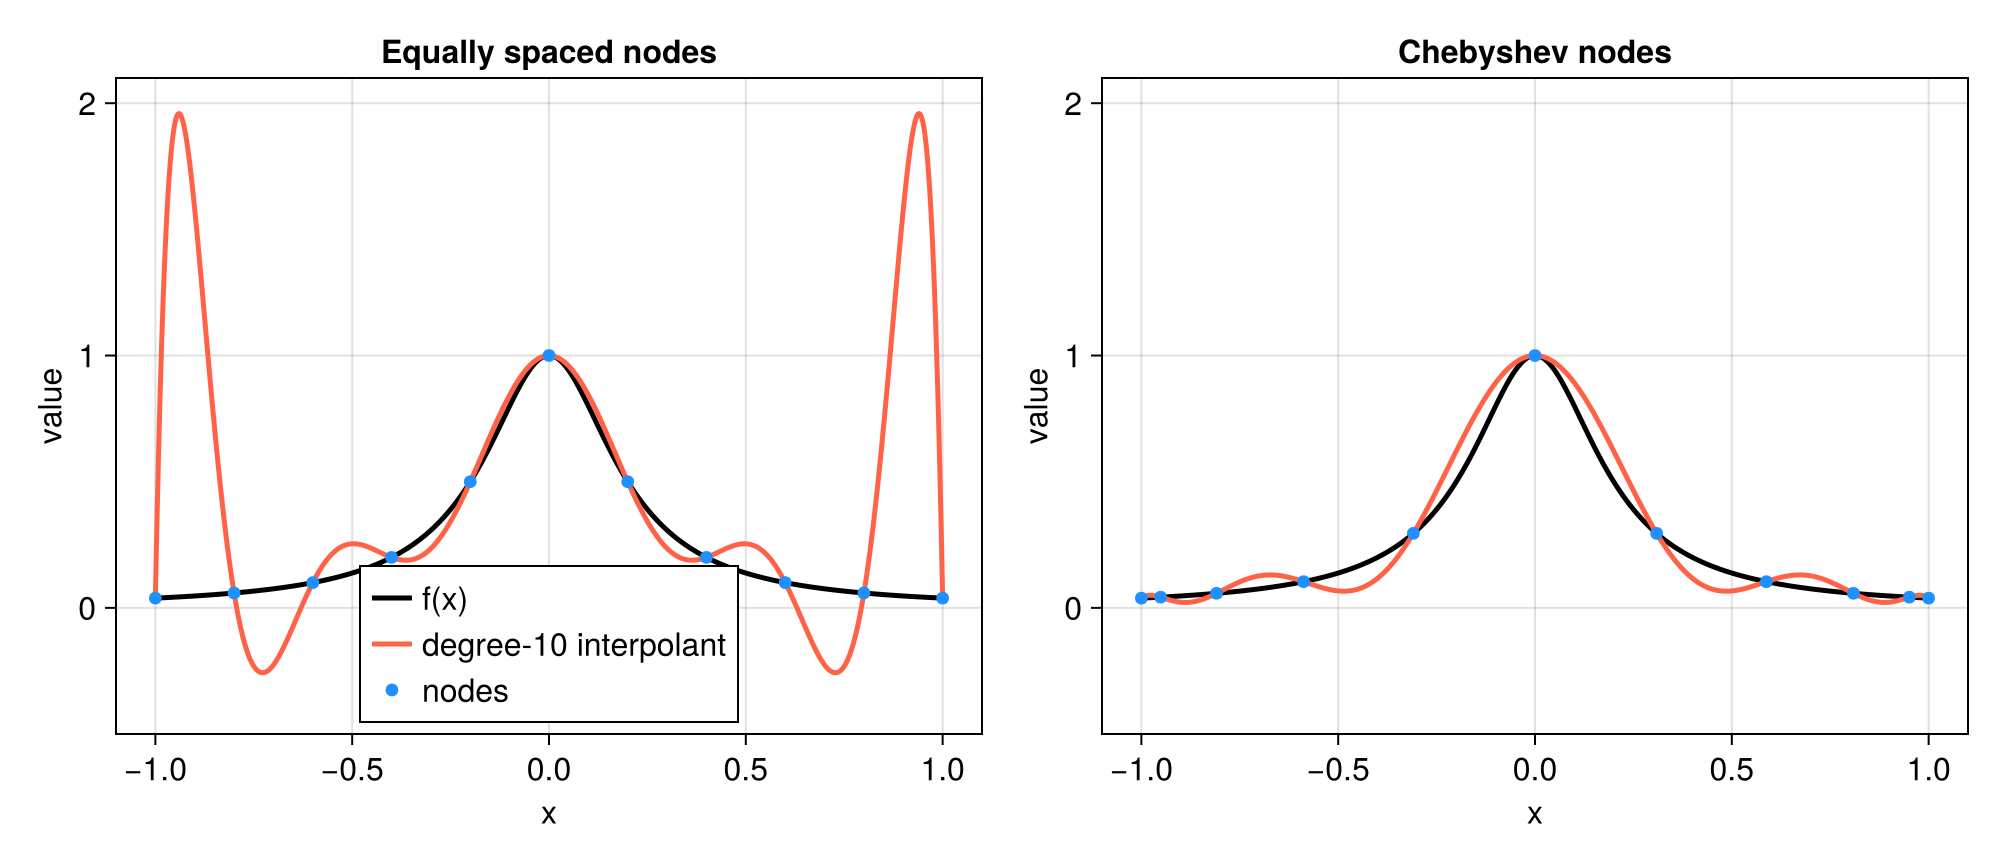

In [11]:
# 初回のみ: import Pkg; Pkg.add("CairoMakie")
using CairoMakie
CairoMakie.activate!(type="svg")
set_theme!(Theme(fontsize=16, linewidth=2.5))
figure_dir = isdir("pic") ? "pic" : joinpath("..", "pic")

runge_plot(x) = 1/(1+25x^2)
function lagrange_plot(nodes, values, x)
    result = zero(x)
    for j in eachindex(nodes)
        basis = one(x)
        for k in eachindex(nodes)
            k == j || (basis *= (x-nodes[k])/(nodes[j]-nodes[k]))
        end
        result += values[j]*basis
    end
    return result
end

n_plot = 11
equal_nodes = collect(range(-1.0, 1.0, length=n_plot))
chebyshev_nodes = sort(cos.((0:n_plot-1) .* π ./ (n_plot-1)))
dense_x = collect(range(-1.0, 1.0, length=800))
equal_values = runge_plot.(equal_nodes)
chebyshev_values = runge_plot.(chebyshev_nodes)
equal_interpolant = [lagrange_plot(equal_nodes, equal_values, x) for x in dense_x]
chebyshev_interpolant = [lagrange_plot(chebyshev_nodes, chebyshev_values, x) for x in dense_x]

fig_interpolation = Figure(size=(1000, 430))
for (column, nodes, values, interpolant, title) in (
    (1, equal_nodes, equal_values, equal_interpolant, "Equally spaced nodes"),
    (2, chebyshev_nodes, chebyshev_values, chebyshev_interpolant, "Chebyshev nodes"))
    ax_nodes = Axis(fig_interpolation[1, column]; xlabel="x", ylabel="value", title=title)
    lines!(ax_nodes, dense_x, runge_plot.(dense_x); color=:black, label="f(x)")
    lines!(ax_nodes, dense_x, interpolant; color=:tomato, label="degree-10 interpolant")
    scatter!(ax_nodes, nodes, values; color=:dodgerblue, markersize=9, label="nodes")
    ylims!(ax_nodes, -0.5, 2.1)
    column == 1 && axislegend(ax_nodes; position=:cb)
end
save(joinpath(figure_dir, "interpolation_node_placement.svg"), fig_interpolation)
fig_interpolation


```{figure} ../pic/interpolation_node_placement.svg
:name: fig-interpolation-node-placement
:width: 90%
:alt: Runge関数に対する等間隔点とChebyshev点の多項式補間

多項式の次数が同じでも、補間点の配置によって端点付近の振動は大きく変わる。高次補間では次数だけでなく点配置が重要である。
```


## $\clubsuit$ Gauss--Legendre積分

直交多項式の節では、異なる次数の成分を内積で分離できることを見た。その直交性は、積分に使う点を選ぶ際にも役立つ。

これまでの複合台形則やSimpson則は、等間隔点で関数を評価した。これに対してGauss型求積法は

$$
\int_{-1}^{1}f(x)\,dx
\approx\sum_{i=1}^{n}w_i f(\xi_i)
$$

の標本点 $\xi_i$ と重み $w_i$ をともに選び、少ない関数評価で高い多項式再現性を得る。

**Gauss--Legendre積分**では、$n$ 個の標本点をLegendre多項式 $P_n$ の零点に選ぶ。重みを適切に定めると、次数 $2n-1$ 以下のすべての多項式を厳密に積分できる。

この次数が現れる理由を見ておく。$\deg q\leq2n-1$ の多項式は、多項式の除法によって

$$
q(x)=s(x)P_n(x)+r(x),\qquad
\deg s\leq n-1,\quad \deg r\leq n-1
$$

と書ける。直交性により $\int_{-1}^{1}sP_n\,dx=0$ である。また各 $\xi_i$ は $P_n$ の零点なので、求積和の中でも $s(\xi_i)P_n(\xi_i)=0$ となる。重み $w_i$ を次数 $n-1$ 以下の $r$ を厳密に積分するよう選べば、$q$ 全体も厳密に積分される。

最初の公式は次の通りである。

| 点数 $n$ | 標本点 $\xi_i$ | 重み $w_i$ | 厳密に積分できる次数 |
| ---: | --- | --- | ---: |
| 1 | $0$ | $2$ | 1 |
| 2 | $\pm1/\sqrt{3}$ | $1,1$ | 3 |
| 3 | $-\sqrt{3/5},0,\sqrt{3/5}$ | $5/9,8/9,5/9$ | 5 |

一般区間 $[a,b]$ では

$$
x=\frac{a+b}{2}+\frac{b-a}{2}\xi
$$

と変数変換して

$$
\int_a^b f(x)\,dx
\approx\frac{b-a}{2}\sum_{i=1}^n w_i
f\!\left(\frac{a+b}{2}+\frac{b-a}{2}\xi_i\right)
$$

を用いる。Gauss--Legendre積分は滑らかな関数に有効だが、一般の関数を $2n-1$ 次まで厳密に積分するという意味ではない。不連続点や特異点がある場合は、そこで区間を分割する、変数変換を行うなど、関数の性質に応じた工夫が必要である。



In [12]:
function gauss_legendre_rule(n)
    if n == 1
        return [0.0], [2.0]
    elseif n == 2
        node = 1/sqrt(3)
        return [-node, node], [1.0, 1.0]
    elseif n == 3
        node = sqrt(3/5)
        return [-node, 0.0, node], [5/9, 8/9, 5/9]
    else
        error("この例ではn=1,2,3を指定してください")
    end
end

function gauss_legendre(f, a, b, n)
    a < b || error("a < b としてください")
    nodes, weights = gauss_legendre_rule(n)
    center = (a+b)/2
    halfwidth = (b-a)/2
    mapped_nodes = center .+ halfwidth .* nodes
    return halfwidth*sum(weights .* f.(mapped_nodes))
end

# n点公式が2n-1次までの単項式を積分できることを確認する。
for n in 1:3
    errors = Float64[]
    for degree in 0:2n-1
        exact = iseven(degree) ? 2/(degree+1) : 0.0
        approximation = gauss_legendre(x -> x^degree, -1.0, 1.0, n)
        push!(errors, abs(approximation-exact))
    end
    println("n=$n: 次数0〜$(2n-1)の最大誤差 = $(maximum(errors))")
end

# 同じ3点評価でも、点の選び方によって多項式再現性が異なる。
exact_x4 = 2/5
simpson_x4 = simpson(x -> x^4, -1.0, 1.0, 2)
gauss_x4 = gauss_legendre(x -> x^4, -1.0, 1.0, 3)
println("x^4の積分: 真値=$exact_x4, Simpson=$simpson_x4, 3点Gauss--Legendre=$gauss_x4")

exact_exp = exp(1)-exp(-1)
for n in 1:3
    approximation = gauss_legendre(exp, -1.0, 1.0, n)
    println("exp(x), n=$n: 誤差 = $(abs(approximation-exact_exp))")
end


n=1: 次数0〜1の最大誤差 = 0.0
n=2: 次数0〜3の最大誤差 = 2.220446049250313e-16
n=3: 次数0〜5の最大誤差 = 1.1102230246251565e-16
x^4の積分: 真値=0.4, Simpson=0.6666666666666666, 3点Gauss--Legendre=0.4000000000000001
exp(x), n=1: 誤差 = 0.35040238728760276
exp(x), n=2: 誤差 = 0.007706299377872039
exp(x), n=3: 誤差 = 6.54586075912178e-5


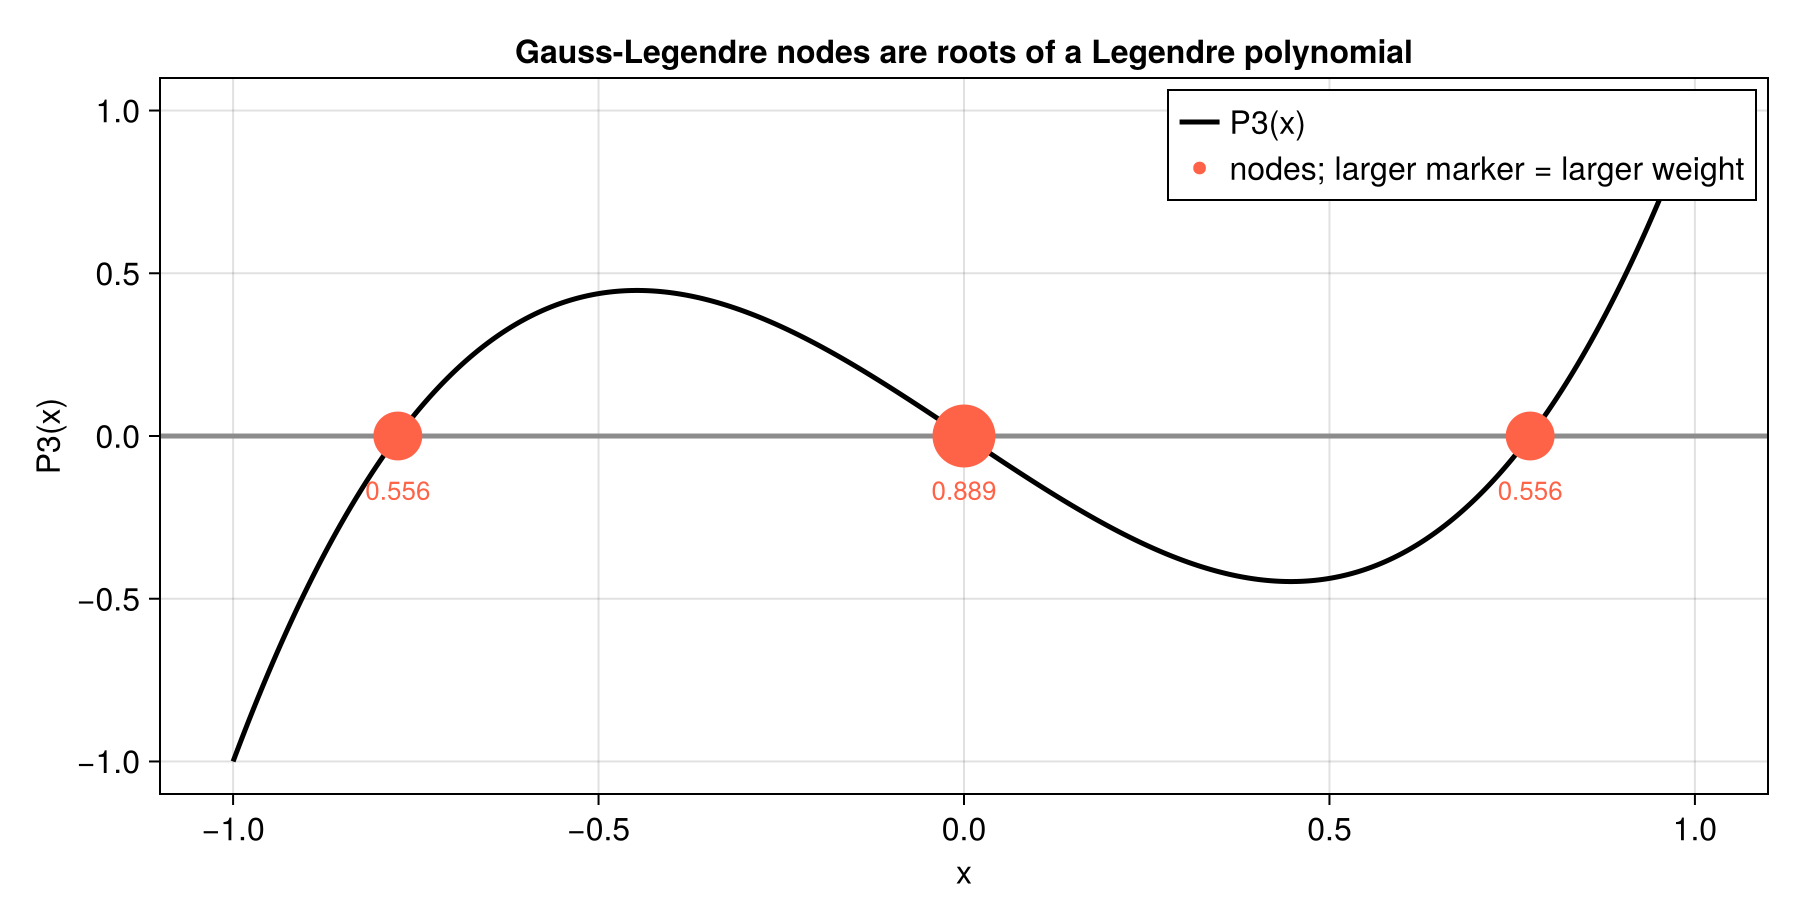

In [13]:
using CairoMakie
CairoMakie.activate!(type="svg")
set_theme!(Theme(fontsize=16, linewidth=2.5))
figure_dir = isdir("pic") ? "pic" : joinpath("..", "pic")

n_gauss = 3
nodes_gauss, weights_gauss = gauss_legendre_rule(n_gauss)
x_gauss = range(-1.0, 1.0, length=700)

fig_gauss = Figure(size=(900, 460))
ax_gauss = Axis(fig_gauss[1, 1]; xlabel="x", ylabel="P3(x)",
    title="Gauss-Legendre nodes are roots of a Legendre polynomial")
lines!(ax_gauss, x_gauss, legendre_plot.(n_gauss, x_gauss); color=:black, label="P3(x)")
hlines!(ax_gauss, [0.0]; color=:gray55)
scatter!(ax_gauss, nodes_gauss, zeros(n_gauss);
    color=:tomato, markersize=18 .+ 30 .* weights_gauss,
    label="nodes; larger marker = larger weight")
for (node, weight) in zip(nodes_gauss, weights_gauss)
    text!(ax_gauss, node, -0.12; text=string(round(weight, digits=3)),
        align=(:center, :top), fontsize=13, color=:tomato)
end
axislegend(ax_gauss; position=:rt)
save(joinpath(figure_dir, "gauss_legendre_nodes.svg"), fig_gauss)
fig_gauss



```{figure} ../pic/gauss_legendre_nodes.svg
:name: fig-gauss-legendre-nodes
:width: 90%
:alt: 3点Gauss--Legendre積分の節点とLegendre多項式P3

赤点は $P_3$ の零点であり、3点Gauss--Legendre積分の節点になる。点の大きさと下の数値は重みを表し、中央に近い節点ほど大きな重みを持つ。
```



## まとめ

`````{admonition} 本章のまとめ
:class: tip

補間・微分・積分は、有限個の関数値から近似を作って利用する方法である。滑らかな関数では、区分線形補間・中心差分・複合台形則の誤差は基本的に2次、複合Simpson則は4次となる。数値微分では細かすぎる刻みが丸めや雑音を増幅するため、次数と実際の誤差を併せて見る。

関数近似は、局所的な関数を張り合わせる方法でも、基底関数を重ね合わせる方法でも構成できる。Lagrange基底は節点で値を合わせるのに適し、直交多項式は区間全体の二乗誤差を小さくする係数を内積から求めるのに適する。基底と係数の決め方を、目的に合わせて選ぶ。

`````

次の[第9章](Chap_InitialValueProblems.ipynb)では、傾きを積分して次の時刻の値を求める。ただし、積分に使いたい未来の状態も未知である点が新しく加わる。

## 演習

本文の式・表・出力を使って説明してよい。

`````{admonition} 演習
:class: attention

1. **2点から3つの量を読む**：$(0,10),(2,14)$ を直線で結び、$x=1$ の値、直線の傾き、$[0,2]$ の積分を求めよ。これはデータの外側を推定する外挿に当たるか。
2. **差分と刻み幅**：$f(x)=x^2$、$x=1$ で $h=0.1$ の前進差分と中心差分を計算し、厳密な微分2と比べよ。一般の関数でも、$h$ を限りなく小さくすればよいと言えるか。
3. **基底の役割**：$x_0=0,x_1=1,x_2=2$ に対する $\ell_0,\ell_1,\ell_2$ の値を各節点で確かめよ。$y_1$ だけを1増やしたとき、2次補間の変化が $\ell_1(x)$ となることを説明せよ。また、帽子型基底を使う区分線形補間では、影響がどこに限られるか述べよ。
4. **直交性と近似**：$f(x)=x^2$ を $[-1,1]$ で $P_0,P_1,P_2$ に展開し、$x^2=\frac13P_0+\frac23P_2$ を確かめよ。$P_0$ だけで近似した定数 $1/3$ は、$x=0$ の関数値を再現するか。補間と二乗誤差最小化の違いを説明せよ。
5. **積分の比較**：$f(x)=x^2$ の $[0,2]$ に対し、2小区間の台形則とSimpson則を使え。節点の値0、1、4を利用し、真値 $8/3$ と比較せよ。
6. **探究：データの積分をどこまで信じるか**：本文の来客ペースのデータで、昼の値（13時の62人/時）が記録ミスで本当は42人/時だったとする。1日の来客数の推定値はどれだけ変わるか。その変化を、台形則とSimpson則の差（離散化の不確かさの目安）と比べよ。次に、自分で「1時間おきより細かいデータが実は滑らかでない」例（例えば、ある30分間だけ来客が集中する）を想定して関数を作り、1時間おきの標本から計算した台形則・Simpson則が真値とどれだけずれるかを調べよ。どの誤差が支配的かを判断するために、何を追加で測ればよいか提案せよ。

`````



## 参考文献と関連する節

- Driscoll and Braun, *Fundamentals of Numerical Computation*, [Finite differences](https://tobydriscoll.net/fnc-julia/localapprox/finitediffs.html).
- NIST Digital Library of Mathematical Functions, [直交多項式の一般的性質](https://dlmf.nist.gov/18.2)、[区間・重みと定義](https://dlmf.nist.gov/18.3)、[近似などへの応用](https://dlmf.nist.gov/18.38)。

